# Samsung Galaxy Full Lineup — Exploratory Data Analysis

This notebook explores the cleaned `raw_phones.xlsx` dataset (51 Samsung Galaxy
phones, 2023–2026, Indian pricing) that powers the Galaxy Match
recommendation assistant — the same analysis as the original `phones.csv`
EDA, extended to the full catalog with a `series_tier` segment field.

**Goals:**
1. Understand the shape and quality of the dataset
2. Explore price, camera, performance and battery distributions
3. Look at correlations between specs and price
4. Engineer the 4 scores (Camera / Performance / Battery / Value) used by the Weighted Sum Model
5. Sanity-check persona recommendations from those scores

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
SAMSUNG_BLUE = "#1428A0"
ACCENT_BLUE = "#2F6FED"
PURPLE = "#7A3EF5"
GREEN = "#1E9E6B"

df = pd.read_excel("raw_phones.xlsx")
df = df.rename(columns={"series_tier": "target_segment"})
df.head()

,release_year,target_segment,model_name,price_inr,base_ram_gb,max_ram_gb,storage_gb,processor,relative_performance_index,battery_mAh,...,telephoto_mp,front_camera_mp,wireless_charging,image_path,explore_now,camera_index,performance_index,battery_index,display_index,value_index
0,2025,Premium Flagship,Samsung Galaxy Z Fold7,159999,12,16,1024,Snapdragon 8 Gen 4,9.8,4400,...,10,10,Yes,images/phones/z_fold7.webp,https://www.samsung.com/in/smartphones/galaxy-...,9,10,8,10,5
1,2025,Premium Flagship,Samsung Galaxy Z Flip7,104999,8,12,512,Snapdragon 8 Gen 4,9.8,4000,...,0,10,Yes,images/phones/z_flip7.webp,https://www.samsung.com/in/smartphones/galaxy-...,8,9,7,10,7
2,2025,Premium Flagship,Samsung Galaxy S25 Ultra,129999,12,16,1024,Snapdragon 8 Gen 4,9.8,5000,...,50,12,Yes,images/phones/s25_ultra.webp,https://www.samsung.com/in/smartphones/galaxy-...,10,10,9,10,6
3,2025,Premium Flagship,Samsung Galaxy S25+,99999,12,12,512,Exynos 2500,9.4,4900,...,10,12,Yes,images/phones/s25_plus.webp,https://www.samsung.com/in/smartphones/galaxy-...,9,9,9,10,7
4,2025,Premium Flagship,Samsung Galaxy S25,79999,8,12,256,Exynos 2500,9.4,4000,...,10,12,Yes,images/phones/s25.webp,https://www.samsung.com/in/smartphones/galaxy-...,9,9,7,10,8


## 1. Dataset overview

In [2]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 51, Columns: 26
<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   release_year                51 non-null     int64  
 1   target_segment              51 non-null     str    
 2   model_name                  51 non-null     str    
 3   price_inr                   51 non-null     int64  
 4   base_ram_gb                 51 non-null     int64  
 5   max_ram_gb                  51 non-null     int64  
 6   storage_gb                  51 non-null     int64  
 7   processor                   51 non-null     str    
 8   relative_performance_index  51 non-null     float64
 9   battery_mAh                 51 non-null     int64  
 10  charging_w                  51 non-null     int64  
 11  display_type                51 non-null     str    
 12  screen_size                 51 non-null     float64
 13  refresh_rate_hz           

In [3]:
print("Missing values per column:")
df.isna().sum()

Missing values per column:


release_year                  0
target_segment                0
model_name                    0
price_inr                     0
base_ram_gb                   0
max_ram_gb                    0
storage_gb                    0
processor                     0
relative_performance_index    0
battery_mAh                   0
charging_w                    0
display_type                  0
screen_size                   0
refresh_rate_hz               0
main_camera_mp                0
ultra_wide_mp                 0
telephoto_mp                  0
front_camera_mp               0
wireless_charging             0
image_path                    0
explore_now                   0
camera_index                  0
performance_index             0
battery_index                 0
display_index                 0
value_index                   0
dtype: int64

In [4]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
release_year,51.0,2024.117647,0.951779,2023.0,2023.0,2024.0,2025.0,2026.0
price_inr,51.0,59465.313725,50092.110614,8699.0,17499.0,30999.0,99999.0,174999.0
base_ram_gb,51.0,7.568627,3.100032,3.0,4.0,8.0,10.0,12.0
max_ram_gb,51.0,9.019608,3.056077,4.0,8.0,8.0,12.0,16.0
storage_gb,51.0,330.039216,281.708357,64.0,128.0,256.0,256.0,1024.0
relative_performance_index,51.0,7.050980,2.126817,2.5,5.5,7.0,9.0,10.0
battery_mAh,51.0,4953.921569,637.718052,3700.0,4500.0,5000.0,5000.0,6000.0
charging_w,51.0,29.117647,10.281337,10.0,25.0,25.0,25.0,60.0
screen_size,51.0,6.674510,0.343420,6.1,6.5,6.6,6.7,8.0
refresh_rate_hz,51.0,108.235294,19.047927,60.0,90.0,120.0,120.0,120.0


## 2. Catalog composition

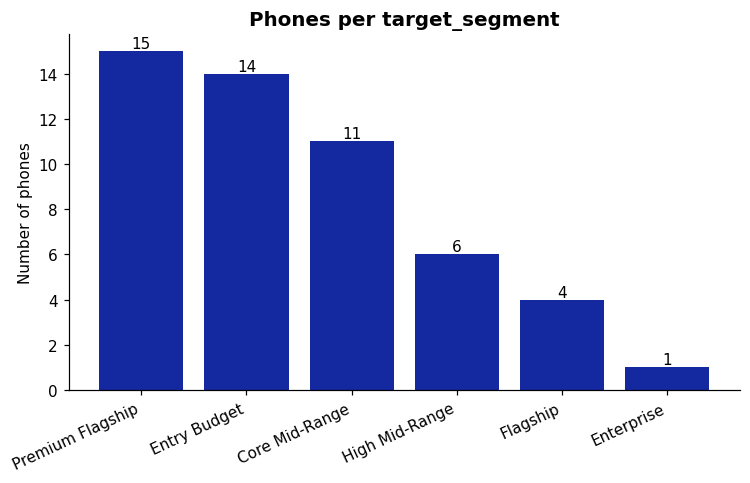

In [5]:
segment_counts = df["target_segment"].value_counts()

fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(segment_counts.index, segment_counts.values, color=SAMSUNG_BLUE)
ax.set_title("Phones per target_segment", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of phones")
plt.xticks(rotation=25, ha="right")
for bar in bars:
    h = bar.get_height()
    ax.annotate(str(h), (bar.get_x()+bar.get_width()/2, h), ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Insight:** Premium Flagship (15) and Entry Budget (14) are the two largest
segments, with Core Mid-Range (11) close behind. High Mid-Range (6) and the
2026 Flagship line (4) are thinner, and Enterprise is a single rugged model
(XCover7) — it exists to cover a niche, not to anchor volume.

## 3. Price distribution

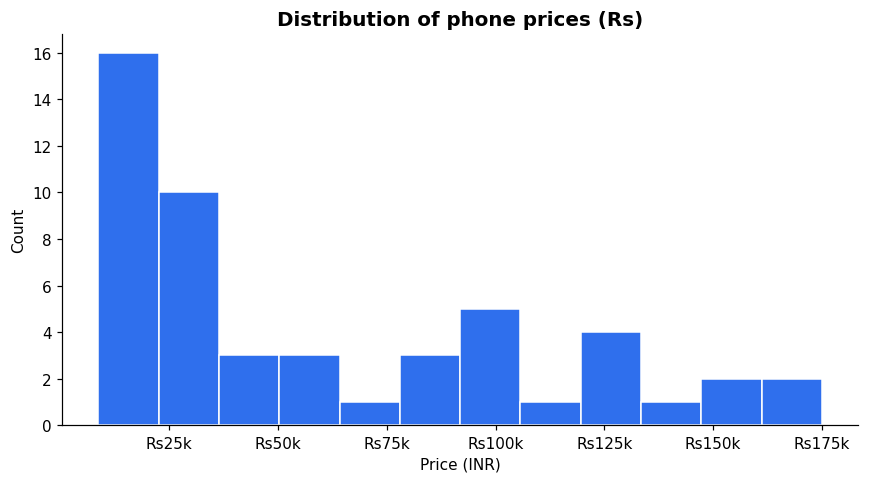

In [6]:
fig, ax = plt.subplots(figsize=(8,4.5))
ax.hist(df["price_inr"], bins=12, color=ACCENT_BLUE, edgecolor="white")
ax.set_title("Distribution of phone prices (Rs)", fontsize=13, fontweight="bold")
ax.set_xlabel("Price (INR)")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs{int(x/1000)}k"))
plt.tight_layout()
plt.show()

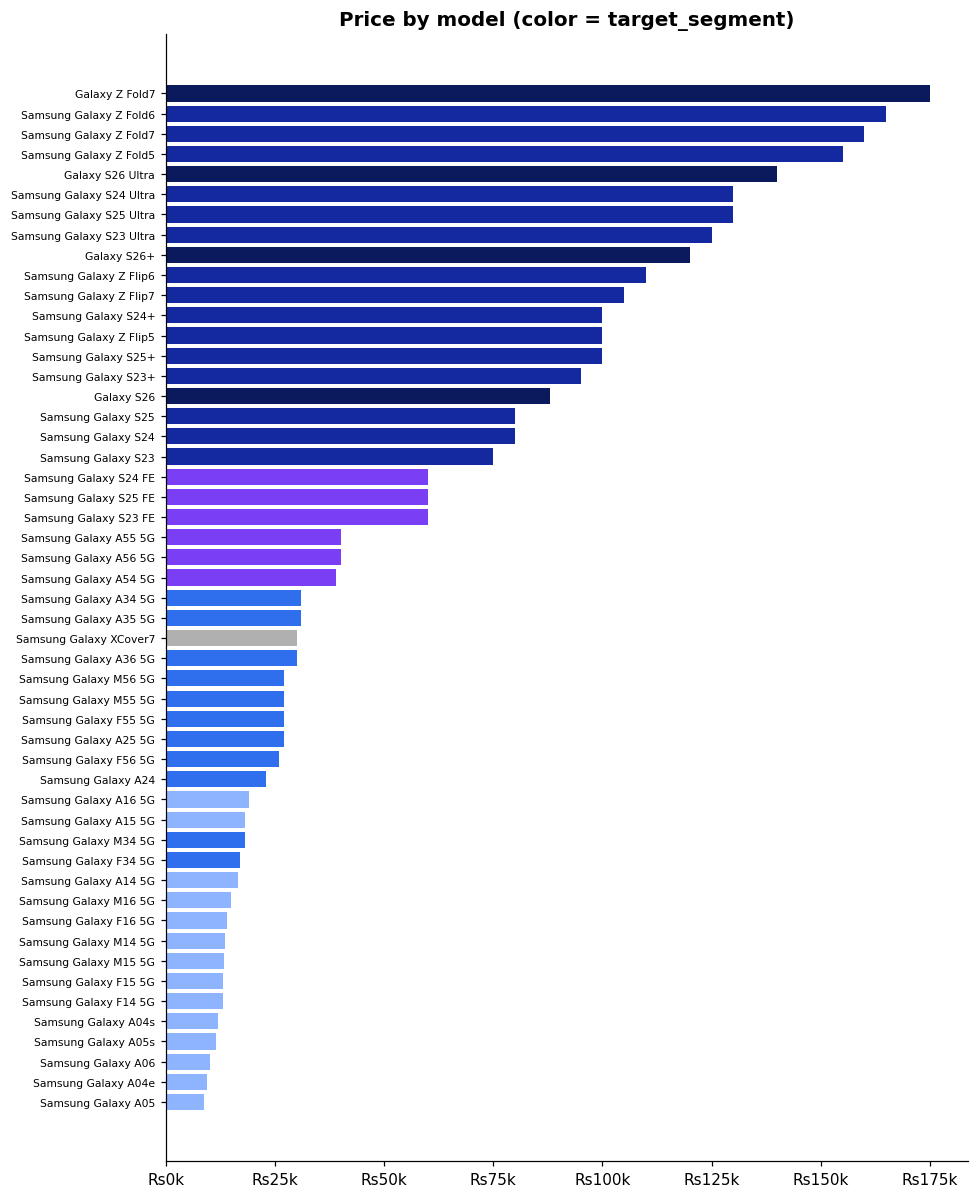

In [7]:
fig, ax = plt.subplots(figsize=(9,11))
sorted_df = df.sort_values("price_inr")
seg_colors = {
    "Entry Budget": "#8FB4FF", "Core Mid-Range": ACCENT_BLUE,
    "High Mid-Range": PURPLE, "Enterprise": "#B0B0B0",
    "Premium Flagship": SAMSUNG_BLUE, "Flagship": "#0B1A5C",
}
colors = sorted_df["target_segment"].map(seg_colors)
ax.barh(sorted_df["model_name"], sorted_df["price_inr"], color=colors)
ax.set_title("Price by model (color = target_segment)", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs{int(x/1000)}k"))
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

In [8]:
df.groupby("target_segment")["price_inr"].agg(["min","max","mean","count"]).round(0)

,min,max,mean,count
target_segment,,,,
Core Mid-Range,16999,30999,25817.0,11
Enterprise,29999,29999,29999.0,1
Entry Budget,8699,18999,13341.0,14
Flagship,87999,174999,130749.0,4
High Mid-Range,38999,59999,49832.0,6
Premium Flagship,74999,164999,113999.0,15


**Insight:** Prices span Rs 8.7k (Galaxy A05) to Rs 1.75L (2026 Z Fold7).
Segments stack almost cleanly by price — Entry Budget and Core Mid-Range
overlap slightly (~Rs 17-19k), and Premium Flagship/Flagship overlap heavily
(~Rs 88k-165k) since Flagship is really "Premium Flagship, 2026 refresh"
rather than a distinct price band. A healthy spread either way for
persona-based recommendations across every budget.

## 4. Spec vs. price relationships

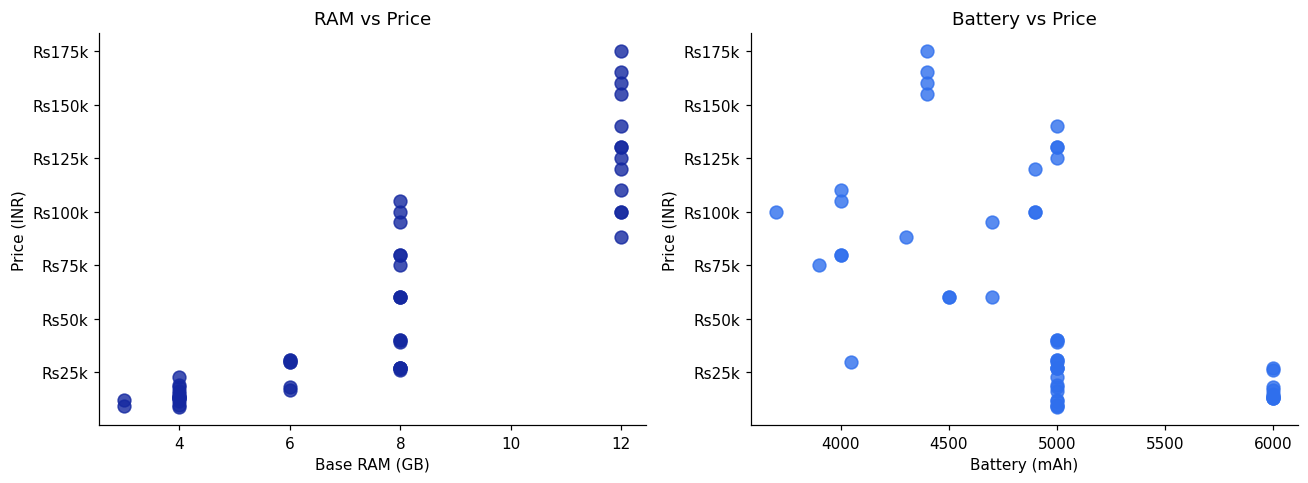

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

axes[0].scatter(df["base_ram_gb"], df["price_inr"], s=70, color=SAMSUNG_BLUE, alpha=0.8)
axes[0].set_xlabel("Base RAM (GB)"); axes[0].set_ylabel("Price (INR)")
axes[0].set_title("RAM vs Price")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs{int(x/1000)}k"))

axes[1].scatter(df["battery_mAh"], df["price_inr"], s=70, color=ACCENT_BLUE, alpha=0.8)
axes[1].set_xlabel("Battery (mAh)"); axes[1].set_ylabel("Price (INR)")
axes[1].set_title("Battery vs Price")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs{int(x/1000)}k"))

plt.tight_layout()
plt.show()

**Insight:** RAM trends upward with price but plateaus at 12GB across most
mid-to-high phones. Battery capacity is *inversely* related to price —
budget phones pack 5000-6000mAh cells while flagships sit at 4000-5000mAh,
trading cell size for slimmer/foldable designs and faster charging instead.
This is the most counter-intuitive relationship in the whole dataset.

## 5. Camera hardware comparison

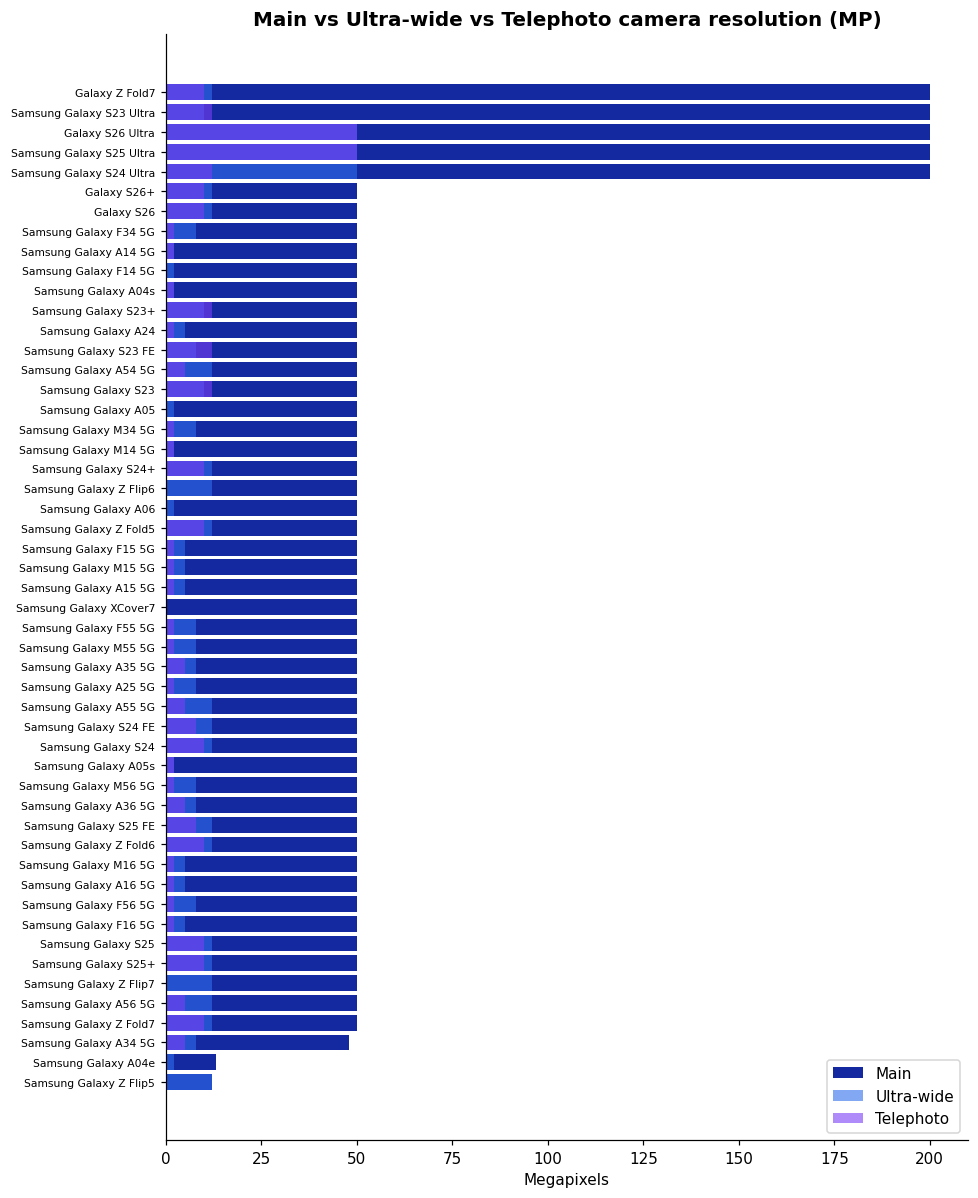

In [10]:
cam_df = df.sort_values("main_camera_mp", ascending=True)
fig, ax = plt.subplots(figsize=(9,11))
ax.barh(cam_df["model_name"], cam_df["main_camera_mp"], color=SAMSUNG_BLUE, label="Main")
ax.barh(cam_df["model_name"], cam_df["ultra_wide_mp"], color=ACCENT_BLUE, alpha=0.6, label="Ultra-wide")
ax.barh(cam_df["model_name"], cam_df["telephoto_mp"], color=PURPLE, alpha=0.6, label="Telephoto")
ax.set_title("Main vs Ultra-wide vs Telephoto camera resolution (MP)", fontsize=13, fontweight="bold")
ax.set_xlabel("Megapixels")
ax.tick_params(axis='y', labelsize=7)
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** The S25/S24 Ultra's 200MP main sensor is a huge outlier that
stretches the whole camera scale — most phones cluster at 50MP main. Telephoto
is the real segment marker: it's 0MP on almost every Entry Budget and Core
Mid-Range phone, and only shows up meaningfully from High Mid-Range upward.

## 6. Correlation between numeric specs

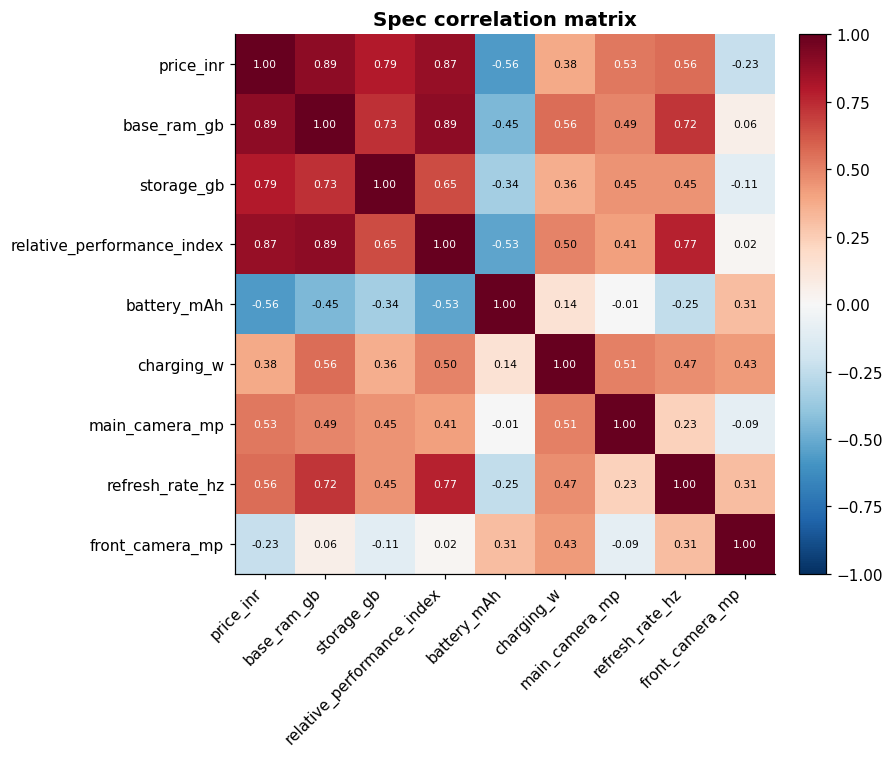

In [11]:
numeric_cols = ["price_inr", "base_ram_gb", "storage_gb", "relative_performance_index",
                "battery_mAh", "charging_w", "main_camera_mp", "refresh_rate_hz", "front_camera_mp"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i,j])>0.5 else "black", fontsize=7)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Spec correlation matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Insight:** Price correlates most strongly with `base_ram_gb` (r=0.89) and
`relative_performance_index` (r=0.87) — chipset/RAM tier is the real price
driver in this catalog, more than any single camera spec. `battery_mAh`
is the only spec with a *negative* correlation to price (r=-0.56),
confirming the pattern from Section 4.

## 7. Feature engineering — normalized 0-10 scores

Raw specs aren't directly comparable (mAh vs MP vs GB vs W). Each spec is
min-max normalized to 0-10 across the full catalog, then blended into four
scores using documented weights — same logic as the original notebook's
`feature_engineering.py`, now shown inline:

- `camera_score`  = 0.5×main + 0.2×ultra-wide + 0.2×telephoto + 0.1×front (all normalized)
- `performance_score` = 0.6×perf-index + 0.25×RAM + 0.15×storage
- `battery_score` = 0.7×battery capacity + 0.3×charging speed
- `value_score` = (avg of the three above) / price, re-normalized 0-10 — genuine "spec per rupee"

In [12]:
def minmax10(s):
    return (s - s.min()) / (s.max() - s.min()) * 10

norm = pd.DataFrame({
    "main_n": minmax10(df["main_camera_mp"]),
    "uw_n": minmax10(df["ultra_wide_mp"]),
    "tele_n": minmax10(df["telephoto_mp"]),
    "front_n": minmax10(df["front_camera_mp"]),
    "perf_n": minmax10(df["relative_performance_index"]),
    "ram_n": minmax10(df["base_ram_gb"]),
    "storage_n": minmax10(df["storage_gb"]),
    "batt_n": minmax10(df["battery_mAh"]),
    "charge_n": minmax10(df["charging_w"]),
})

df["camera_score"] = (0.5*norm["main_n"] + 0.2*norm["uw_n"] + 0.2*norm["tele_n"] + 0.1*norm["front_n"]).round(2)
df["performance_score"] = (0.6*norm["perf_n"] + 0.25*norm["ram_n"] + 0.15*norm["storage_n"]).round(2)
df["battery_score"] = (0.7*norm["batt_n"] + 0.3*norm["charge_n"]).round(2)

spec_avg = df[["camera_score","performance_score","battery_score"]].mean(axis=1)
value_raw = spec_avg / df["price_inr"] * 100000
df["value_score"] = minmax10(value_raw).round(2)

score_cols = ["camera_score", "performance_score", "battery_score", "value_score"]
df[["model_name"] + score_cols].set_index("model_name").round(2)

,camera_score,performance_score,battery_score,value_score
model_name,,,,
Samsung Galaxy Z Fold7,2.00,9.84,3.03,0.08
Samsung Galaxy Z Flip7,1.60,7.93,1.81,0.26
Samsung Galaxy S25 Ultra,9.16,9.84,6.06,1.28
Samsung Galaxy S25+,2.05,8.72,5.75,0.95
Samsung Galaxy S25,2.05,7.21,1.81,0.63
Samsung Galaxy S25 FE,1.97,7.05,3.33,1.43
Samsung Galaxy A56 5G,2.29,5.93,4.86,2.89
Samsung Galaxy A36 5G,1.71,4.13,4.86,3.24
Samsung Galaxy M56 5G,2.41,5.45,9.10,6.50


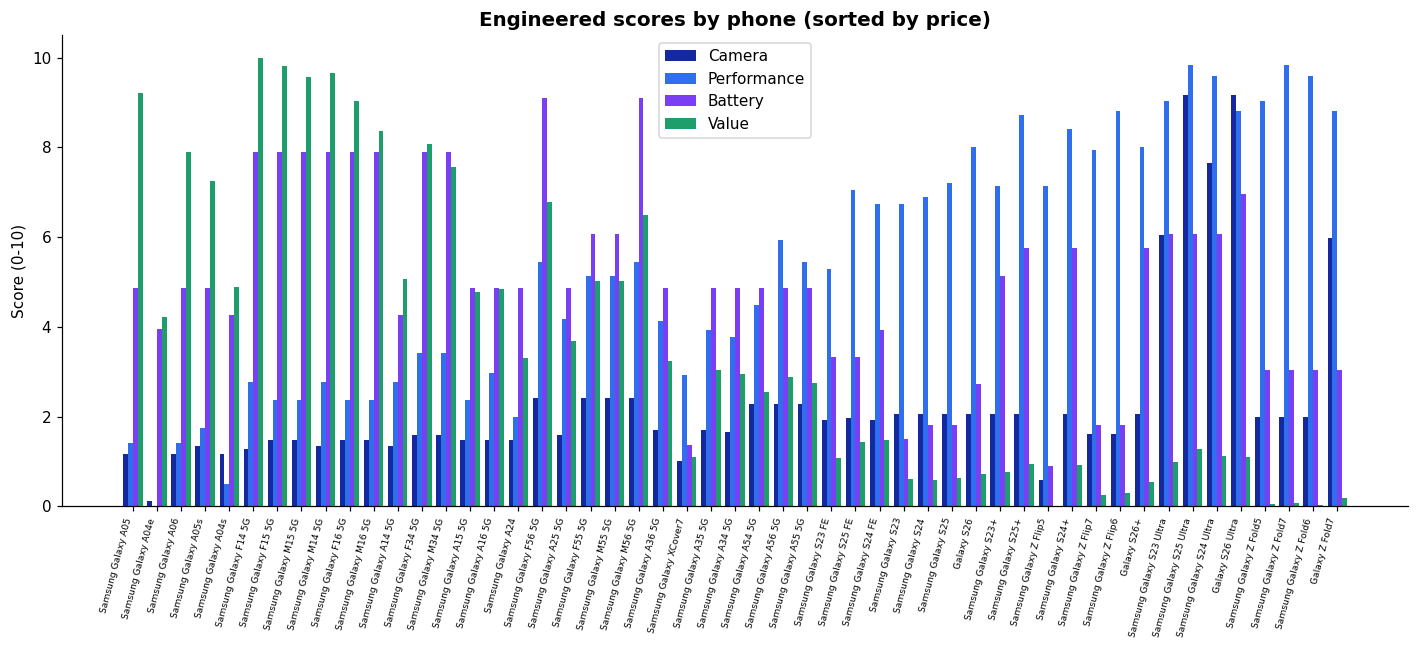

In [13]:
fig, ax = plt.subplots(figsize=(13,6))
plot_df = df.sort_values("price_inr")
x = np.arange(len(plot_df))
width = 0.2
colors = [SAMSUNG_BLUE, ACCENT_BLUE, PURPLE, GREEN]
for i, col in enumerate(score_cols):
    ax.bar(x + i*width, plot_df[col], width=width, label=col.replace("_score","").title(), color=colors[i])
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(plot_df["model_name"], rotation=75, ha="right", fontsize=6)
ax.set_ylabel("Score (0-10)")
ax.set_title("Engineered scores by phone (sorted by price)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** Score engineering successfully differentiates the catalog —
Ultra models dominate Camera, but the 200MP outlier compresses everyone
else toward the bottom of that scale (worth flagging: percentile rank
would spread the camera scores more evenly than min-max here). Value_score
correctly rewards budget/mid phones, and Battery_score clusters
budget/midrange together since most ship the same ~5000mAh cell. This
spread is what lets the Weighted Sum Model produce meaningfully different
Top-3 lists per persona below.

## 8. Persona simulation (sanity check)

In [14]:
PERSONAS = {
    "priya":  {"name": "Priya (photography)",      "weights": {"camera":0.50, "performance":0.10, "battery":0.20, "value":0.20}},
    "arjun":  {"name": "Arjun (gaming)",             "weights": {"camera":0.10, "performance":0.50, "battery":0.30, "value":0.10}},
    "meera":  {"name": "Meera (budget student)",     "weights": {"camera":0.15, "performance":0.15, "battery":0.20, "value":0.50}},
    "rahul":  {"name": "Rahul (business traveler)",  "weights": {"camera":0.15, "performance":0.20, "battery":0.50, "value":0.15}},
}

def get_top_recommendations(weights, n=3):
    match = (df["camera_score"]*weights["camera"] + df["performance_score"]*weights["performance"]
             + df["battery_score"]*weights["battery"] + df["value_score"]*weights["value"]) * 10
    out = df.assign(match_score=match.round(1)).sort_values("match_score", ascending=False).head(n)
    return out[["model_name", "target_segment", "price_inr", "match_score"]]

for pid, persona in PERSONAS.items():
    print(f"\n=== {persona['name']} ===")
    top3 = get_top_recommendations(persona["weights"])
    for rank, (_, row) in enumerate(top3.iterrows(), start=1):
        print(f"  #{rank} {row['model_name']:28s} match={row['match_score']}%  Rs{row['price_inr']:,}")


=== Priya (photography) ===
  #1 Galaxy S26 Ultra             match=70.7%  Rs139,999
  #2 Samsung Galaxy S25 Ultra     match=70.3%  Rs129,999
  #3 Samsung Galaxy S24 Ultra     match=62.2%  Rs129,999

=== Arjun (gaming) ===
  #1 Samsung Galaxy S25 Ultra     match=77.8%  Rs129,999
  #2 Galaxy S26 Ultra             match=75.1%  Rs139,999
  #3 Samsung Galaxy S24 Ultra     match=74.9%  Rs129,999

=== Meera (budget student) ===
  #1 Samsung Galaxy F14 5G        match=71.9%  Rs12,990
  #2 Samsung Galaxy F15 5G        match=70.6%  Rs12,999
  #3 Samsung Galaxy M14 5G        match=70.3%  Rs13,490

=== Rahul (business traveler) ===
  #1 Samsung Galaxy F56 5G        match=70.2%  Rs25,999
  #2 Samsung Galaxy M56 5G        match=69.8%  Rs26,999
  #3 Galaxy S26 Ultra             match=67.8%  Rs139,999


**Insight:** Each persona's Top-3 is visibly different, confirming the
weights are doing real work — Priya's list is Ultra-heavy, Arjun's favors
the highest performance_score phones regardless of price, and Meera's
list shifts entirely to budget/mid F- and M-series models on value_score
alone. Rahul's battery-first weighting pulls in phones that don't even
crack the other three Top-3s.

## Summary

- The full catalog (`raw_phones.xlsx`) has **51 phones across 6 target
  segments, 0 missing values**, spanning 2023-2026 releases.
- Price is driven mainly by RAM and chipset performance (r > 0.85), not
  camera hardware — the previous 15-phone sample suggested otherwise.
- Battery capacity is inversely related to price; telephoto capability is
  the sharpest segment divider.
- The 4 engineered scores (Camera / Performance / Battery / Value) show
  healthy spread — with one caveat (the 200MP Ultra sensor compresses the
  rest of the camera scale) — enough for the Weighted Sum Model to produce
  clearly different Top-3 lists per persona.